# Count calibration for CAPY vs ProCapNet

This notebook fits simple post-hoc count calibrators on each fold's validation predictions and evaluates them on that fold's held-out test predictions. It uses only saved count prediction artifacts plus the observed PRO-cap signal tracks needed to reconstruct true total counts.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import gzip
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyBigWig
from scipy.stats import spearmanr

warnings.filterwarnings("ignore", category=RuntimeWarning)


@dataclass(frozen=True)
class CalibrationArtifacts:
    model: str
    model_name: str
    timestamp: str
    fold: int
    mode: str
    a: float
    b: float
    val_true: np.ndarray
    val_pred: np.ndarray
    test_true: np.ndarray
    test_pred_raw: np.ndarray
    test_pred_calibrated: np.ndarray


## Configuration

Prediction files must already exist from `examples/procap/evaluate.py --save_predictions` for both `val` and `test` splits.

In [2]:
proj_dir = Path("/grid/koo/home/shared/capybara/procap")
cell_type = "K562"
data_type = "procap"
folds = [1, 2, 3, 4, 5, 6, 7]
rc_augmented = True
calibration_modes = ["affine", "offset_only"]

model_specs = [
    {"label": "ProCapNet", "model_name": "procapnet", "timestamp": "260509", "color": "#808080"},
    {"label": "CAPY", "model_name": "capy", "timestamp": "260511", "color": "#1565C0"},
]

figures_dir = Path("examples/procap/figures_count_calibration")
figures_dir.mkdir(parents=True, exist_ok=True)

allowed_modes = {"affine", "offset_only"}
unknown_modes = sorted(set(calibration_modes) - allowed_modes)
if unknown_modes:
    raise ValueError(f"Unsupported calibration modes: {unknown_modes}")


In [3]:
def _find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "examples" / "procap" / "file_config.py").exists():
            return path
    raise FileNotFoundError("Could not find repo root containing examples/procap/file_config.py")


REPO_ROOT = _find_repo_root()
EXAMPLES_PROCAP_DIR = REPO_ROOT / "examples" / "procap"
if str(EXAMPLES_PROCAP_DIR) not in sys.path:
    sys.path.insert(0, str(EXAMPLES_PROCAP_DIR))

from file_config import FoldFilesConfig


def get_fold_config(model_name: str, timestamp: str, fold: int) -> FoldFilesConfig:
    return FoldFilesConfig.create(
        proj_dir=proj_dir,
        cell_type=cell_type,
        data_type=data_type,
        fold=int(fold),
        model_name=model_name,
        timestamp=timestamp,
        use_unmappability_mask=False,
    )


def split_peak_path(cfg: FoldFilesConfig, split: str) -> Path:
    if split == "val":
        return cfg.val_peak_path
    if split == "test":
        return cfg.test_peak_path
    raise ValueError(f"Unsupported split: {split}")


def pred_count_path(cfg: FoldFilesConfig, split: str) -> Path:
    rc_suffix = "_rc" if rc_augmented else ""
    return Path(cfg.eval_dir) / f"{cell_type}_log_pred_counts{rc_suffix}_{split}.npy"


def _load_lines(path: Path) -> list[list[str]]:
    if str(path).endswith(".gz"):
        with gzip.open(path, "rt") as handle:
            return [line.split() for line in handle if line.strip()]
    with path.open() as handle:
        return [line.split() for line in handle if line.strip()]


def _bw_values_padded(bw, chrom: str, start: int, end: int) -> np.ndarray:
    chrom_sizes = bw.chroms()
    if chrom not in chrom_sizes:
        raise KeyError(f"Chromosome {chrom} not found in BigWig")
    chrom_len = chrom_sizes[chrom]
    q_start = max(start, 0)
    q_end = min(end, chrom_len)
    width = end - start
    if q_start >= q_end:
        return np.zeros(width, dtype=np.float32)
    values = bw.values(chrom, q_start, q_end, numpy=True)
    arr = np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    left_pad = q_start - start
    right_pad = end - q_end
    if left_pad > 0 or right_pad > 0:
        arr = np.pad(arr, (left_pad, right_pad), mode="constant")
    return arr


def load_true_log_counts(cfg: FoldFilesConfig, split: str, output_length: int) -> np.ndarray:
    lines = _load_lines(split_peak_path(cfg, split))
    plus_bw = pyBigWig.open(str(cfg.plus_bw_path), "r")
    minus_bw = pyBigWig.open(str(cfg.minus_bw_path), "r")
    totals = []
    try:
        for fields in lines:
            chrom, start, end = fields[0], int(fields[1]), int(fields[2])
            mid = (start + end) // 2
            window_start = mid - output_length // 2
            window_end = window_start + output_length
            plus = _bw_values_padded(plus_bw, chrom, window_start, window_end)
            minus = _bw_values_padded(minus_bw, chrom, window_start, window_end)
            totals.append(float(plus.sum() + minus.sum()))
    finally:
        plus_bw.close()
        minus_bw.close()
    return np.log1p(np.asarray(totals, dtype=np.float64))


In [4]:
def fit_calibration(y_true: np.ndarray, y_pred: np.ndarray, mode: str) -> tuple[float, float]:
    if y_true.shape != y_pred.shape:
        raise ValueError(f"Validation shape mismatch: true={y_true.shape}, pred={y_pred.shape}")
    if mode == "offset_only":
        return 1.0, float(np.mean(y_true - y_pred))
    if mode == "affine":
        design = np.column_stack([y_pred, np.ones_like(y_pred)])
        a, b = np.linalg.lstsq(design, y_true, rcond=None)[0]
        return float(a), float(b)
    raise ValueError(f"Unsupported calibration mode: {mode}")


def apply_calibration(y_pred: np.ndarray, a: float, b: float) -> np.ndarray:
    return a * y_pred + b


def compute_count_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    if y_true.shape != y_pred.shape:
        raise ValueError(f"Metric shape mismatch: true={y_true.shape}, pred={y_pred.shape}")
    finite = np.isfinite(y_true) & np.isfinite(y_pred)
    if not np.any(finite):
        raise ValueError("No finite values available for metric computation")
    truth = y_true[finite]
    pred = y_pred[finite]
    pearson = float(np.corrcoef(pred, truth)[0, 1])
    spearman = float(spearmanr(pred, truth).correlation)
    mse = float(np.mean((truth - pred) ** 2))
    ss_res = float(np.sum((truth - pred) ** 2))
    ss_tot = float(np.sum((truth - np.mean(truth)) ** 2))
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float("nan")
    return {"pearson": pearson, "spearman": spearman, "mse": mse, "r2": r2}


In [5]:
artifacts: list[CalibrationArtifacts] = []

for spec in model_specs:
    for fold in folds:
        cfg = get_fold_config(spec["model_name"], spec["timestamp"], fold)
        params_path = Path(cfg.params_path)
        if not params_path.exists():
            raise FileNotFoundError(f"Missing params file for {spec['label']} fold {fold}: {params_path}")

        import yaml

        with params_path.open() as handle:
            params = yaml.safe_load(handle)
        output_length = int(params["dataset"]["output_length"])

        val_pred_path = pred_count_path(cfg, "val")
        test_pred_path = pred_count_path(cfg, "test")
        if not val_pred_path.exists():
            raise FileNotFoundError(f"Missing validation count predictions: {val_pred_path}")
        if not test_pred_path.exists():
            raise FileNotFoundError(f"Missing test count predictions: {test_pred_path}")

        val_pred = np.asarray(np.load(val_pred_path)).reshape(-1).astype(np.float64)
        test_pred = np.asarray(np.load(test_pred_path)).reshape(-1).astype(np.float64)
        val_true = load_true_log_counts(cfg, "val", output_length)
        test_true = load_true_log_counts(cfg, "test", output_length)

        if val_true.shape != val_pred.shape:
            raise ValueError(
                f"Validation length mismatch for {spec['label']} fold {fold}: "
                f"true={val_true.shape}, pred={val_pred.shape}"
            )
        if test_true.shape != test_pred.shape:
            raise ValueError(
                f"Test length mismatch for {spec['label']} fold {fold}: "
                f"true={test_true.shape}, pred={test_pred.shape}"
            )

        for mode in calibration_modes:
            a, b = fit_calibration(val_true, val_pred, mode)
            calibrated_test = apply_calibration(test_pred, a, b)
            artifacts.append(
                CalibrationArtifacts(
                    model=spec["label"],
                    model_name=spec["model_name"],
                    timestamp=spec["timestamp"],
                    fold=int(fold),
                    mode=mode,
                    a=a,
                    b=b,
                    val_true=val_true,
                    val_pred=val_pred,
                    test_true=test_true,
                    test_pred_raw=test_pred,
                    test_pred_calibrated=calibrated_test,
                )
            )

print(f"Prepared {len(artifacts)} calibrated model-fold-mode combinations.")


Prepared 28 calibrated model-fold-mode combinations.


In [6]:
param_rows = []
metric_rows = []

for item in artifacts:
    raw_metrics = compute_count_metrics(item.test_true, item.test_pred_raw)
    calibrated_metrics = compute_count_metrics(item.test_true, item.test_pred_calibrated)
    param_rows.append(
        {"model": item.model, "fold": item.fold, "mode": item.mode, "a": item.a, "b": item.b}
    )
    metric_rows.append(
        {
            "model": item.model,
            "model_name": item.model_name,
            "timestamp": item.timestamp,
            "fold": item.fold,
            "mode": item.mode,
            "a": item.a,
            "b": item.b,
            "raw_count_pearson": raw_metrics["pearson"],
            "calibrated_count_pearson": calibrated_metrics["pearson"],
            "raw_count_spearman": raw_metrics["spearman"],
            "calibrated_count_spearman": calibrated_metrics["spearman"],
            "raw_count_mse": raw_metrics["mse"],
            "calibrated_count_mse": calibrated_metrics["mse"],
            "delta_count_mse": calibrated_metrics["mse"] - raw_metrics["mse"],
            "raw_count_r2": raw_metrics["r2"],
            "calibrated_count_r2": calibrated_metrics["r2"],
            "delta_count_r2": calibrated_metrics["r2"] - raw_metrics["r2"],
        }
    )

calibration_params_df = pd.DataFrame(param_rows).sort_values(["model", "mode", "fold"]).reset_index(drop=True)
results_per_fold_df = pd.DataFrame(metric_rows).sort_values(["model", "mode", "fold"]).reset_index(drop=True)
summary_df = (
    results_per_fold_df.groupby(["model", "mode"], as_index=False)[
        [
            "raw_count_mse",
            "calibrated_count_mse",
            "delta_count_mse",
            "raw_count_r2",
            "calibrated_count_r2",
            "delta_count_r2",
            "raw_count_pearson",
            "calibrated_count_pearson",
            "raw_count_spearman",
            "calibrated_count_spearman",
        ]
    ].mean()
)

display(calibration_params_df)
display(results_per_fold_df)
display(summary_df)


,model,fold,mode,a,b
0,CAPY,1,affine,0.738036,1.796366
1,CAPY,2,affine,0.726287,2.052909
2,CAPY,3,affine,0.796964,1.673497
3,CAPY,4,affine,0.711089,2.023305
4,CAPY,5,affine,0.718478,1.890591
5,CAPY,6,affine,0.618889,2.347571
6,CAPY,7,affine,0.708383,2.082702
7,CAPY,1,offset_only,1.000000,0.342054
8,CAPY,2,offset_only,1.000000,0.593918
9,CAPY,3,offset_only,1.000000,0.608444


,model,model_name,timestamp,fold,mode,a,b,raw_count_pearson,calibrated_count_pearson,raw_count_spearman,calibrated_count_spearman,raw_count_mse,calibrated_count_mse,delta_count_mse,raw_count_r2,calibrated_count_r2,delta_count_r2
0,CAPY,capy,260511,1,affine,0.738036,1.796366,0.749492,0.749492,0.779032,0.779032,1.174095,0.801615,-0.372481,0.337559,0.547718,0.210159
1,CAPY,capy,260511,2,affine,0.726287,2.052909,0.769828,0.769828,0.789723,0.789723,0.854267,0.667627,-0.186640,0.446885,0.567730,0.120844
2,CAPY,capy,260511,3,affine,0.796964,1.673497,0.760915,0.760915,0.782514,0.782514,1.247278,0.723334,-0.523944,0.265474,0.574027,0.308552
3,CAPY,capy,260511,4,affine,0.711089,2.023305,0.751951,0.751951,0.782666,0.782666,1.124654,0.737262,-0.387392,0.335627,0.564474,0.228846
4,CAPY,capy,260511,5,affine,0.718478,1.890591,0.745284,0.745284,0.766467,0.766467,1.011055,0.665862,-0.345192,0.318187,0.550971,0.232783
5,CAPY,capy,260511,6,affine,0.618889,2.347571,0.749308,0.749308,0.763769,0.763769,0.912302,0.653769,-0.258533,0.378045,0.554298,0.176253
6,CAPY,capy,260511,7,affine,0.708383,2.082702,0.694019,0.694019,0.737242,0.737242,1.017104,0.786438,-0.230666,0.268534,0.434421,0.165887
7,CAPY,capy,260511,1,offset_only,1.000000,0.342054,0.749492,0.749492,0.779032,0.779032,1.174095,0.921767,-0.252328,0.337559,0.479926,0.142367
8,CAPY,capy,260511,2,offset_only,1.000000,0.593918,0.769828,0.769828,0.789723,0.789723,0.854267,0.807043,-0.047224,0.446885,0.477462,0.030576
9,CAPY,capy,260511,3,offset_only,1.000000,0.608444,0.760915,0.760915,0.782514,0.782514,1.247278,0.767775,-0.479503,0.265474,0.547855,0.282381


,model,mode,raw_count_mse,calibrated_count_mse,delta_count_mse,raw_count_r2,calibrated_count_r2,delta_count_r2,raw_count_pearson,calibrated_count_pearson,raw_count_spearman,calibrated_count_spearman
0,CAPY,affine,1.048679,0.719415,-0.329264,0.335759,0.541948,0.206189,0.745828,0.745828,0.771630,0.771630
1,CAPY,offset_only,1.048679,0.865434,-0.183245,0.335759,0.446173,0.110414,0.745828,0.745828,0.771630,0.771630
2,ProCapNet,affine,0.887482,0.782756,-0.104726,0.436470,0.501939,0.065469,0.720367,0.720367,0.727142,0.727142
3,ProCapNet,offset_only,0.887482,0.895165,0.007683,0.436470,0.430235,-0.006235,0.720367,0.720367,0.727142,0.727142


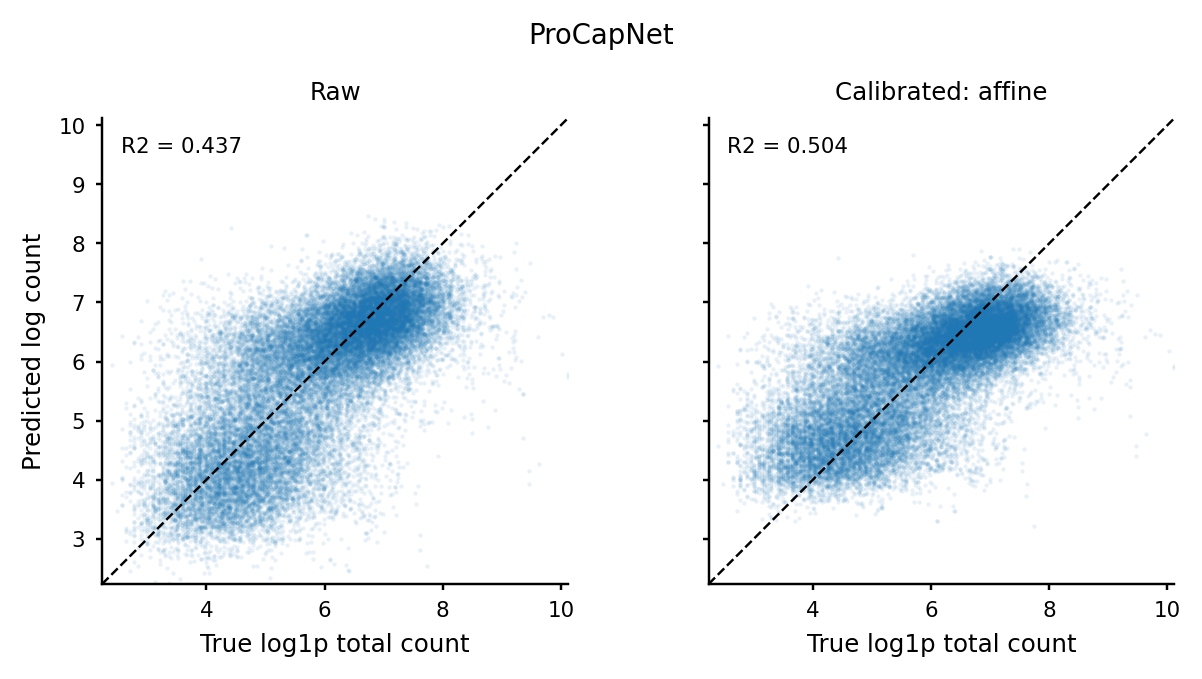

saved: examples/procap/figures_count_calibration/count_scatter_procapnet_affine.pdf


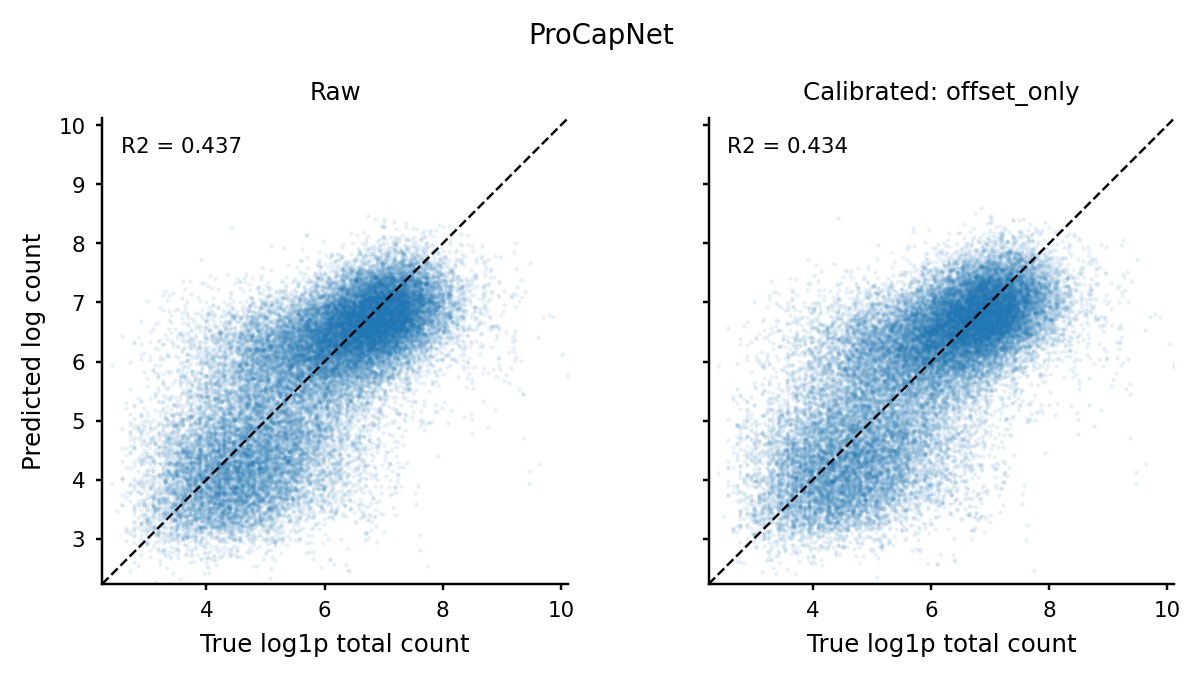

saved: examples/procap/figures_count_calibration/count_scatter_procapnet_offset_only.pdf


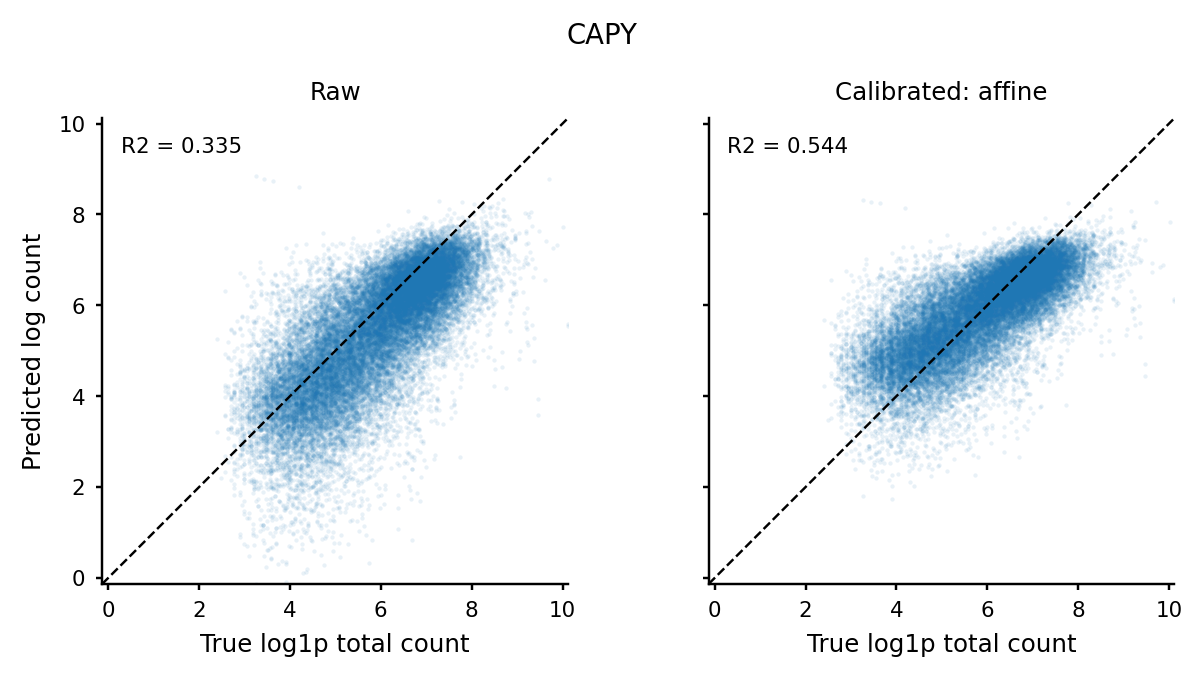

saved: examples/procap/figures_count_calibration/count_scatter_capy_affine.pdf


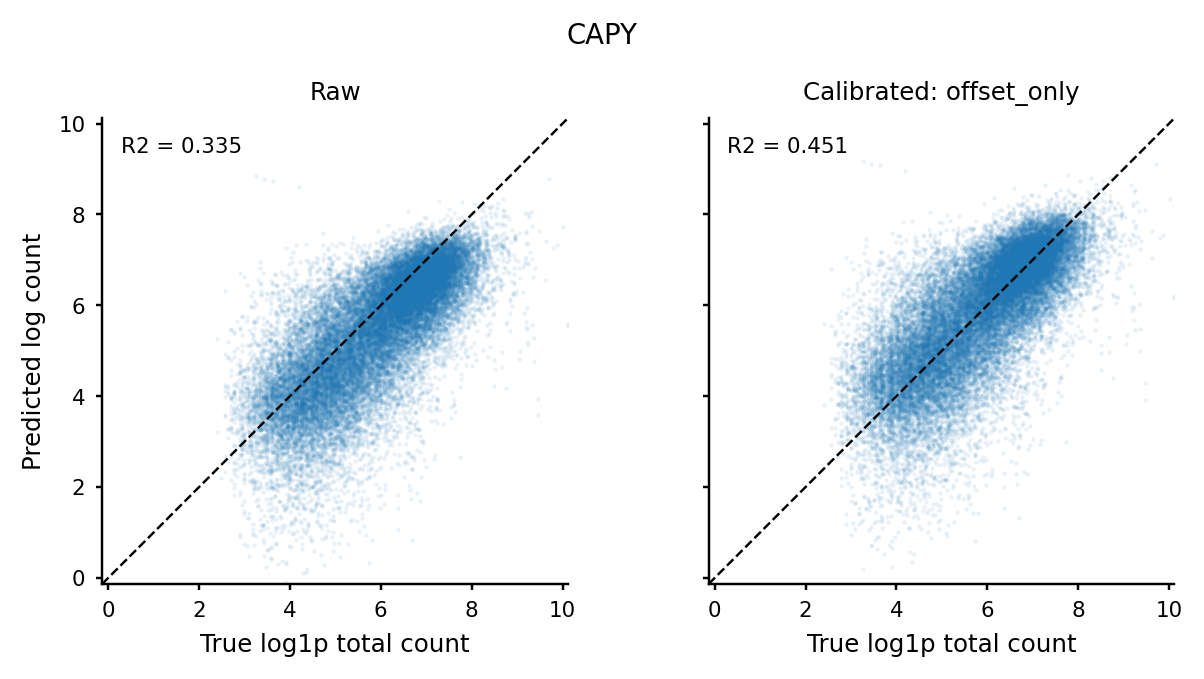

saved: examples/procap/figures_count_calibration/count_scatter_capy_offset_only.pdf


In [ ]:
def plot_test_scatter(model_label: str, mode: str) -> None:
    selected = [item for item in artifacts if item.model == model_label and item.mode == mode]
    if not selected:
        raise ValueError(f"No artifacts found for model={model_label}, mode={mode}")
    truth = np.concatenate([item.test_true for item in selected])
    raw = np.concatenate([item.test_pred_raw for item in selected])
    calibrated = np.concatenate([item.test_pred_calibrated for item in selected])

    fig, axes = plt.subplots(1, 2, figsize=(6.0, 3.0), dpi=220, sharex=True, sharey=True)
    limits = [float(min(truth.min(), raw.min(), calibrated.min())), float(max(truth.max(), raw.max(), calibrated.max()))]
    panels = [(raw, "Raw"), (calibrated, f"Calibrated: {mode}")]
    for ax, (pred, title) in zip(axes, panels):
        r2 = compute_count_metrics(truth, pred)["r2"]
        ax.scatter(truth, pred, s=2, alpha=0.1, linewidths=0)
        ax.plot(limits, limits, color="black", linewidth=0.8, linestyle="--")
        ax.set_xlim(limits)
        ax.set_ylim(limits)
        ax.set_aspect("equal", adjustable="box")
        ax.set_title(title, fontsize=8)
        ax.text(0.04, 0.96, f"R2 = {r2:.3f}", transform=ax.transAxes, ha="left", va="top", fontsize=7)
        ax.set_xlabel("Measured log(1 + count)", fontsize=8)
        ax.tick_params(length=2, labelsize=7)
        ax.spines[["top", "right"]].set_visible(False)
    axes[0].set_ylabel("Predicted log (1 + count)", fontsize=8)
    fig.suptitle(model_label, fontsize=9)
    fig.tight_layout()
    out = figures_dir / f"count_scatter_{model_label.lower().replace(' ', '_')}_{mode}.pdf"
    fig.savefig(out, bbox_inches="tight", pad_inches=0.02)
    plt.show()
    print("saved:", out)


for spec in model_specs:
    for mode in calibration_modes:
        plot_test_scatter(spec["label"], mode)


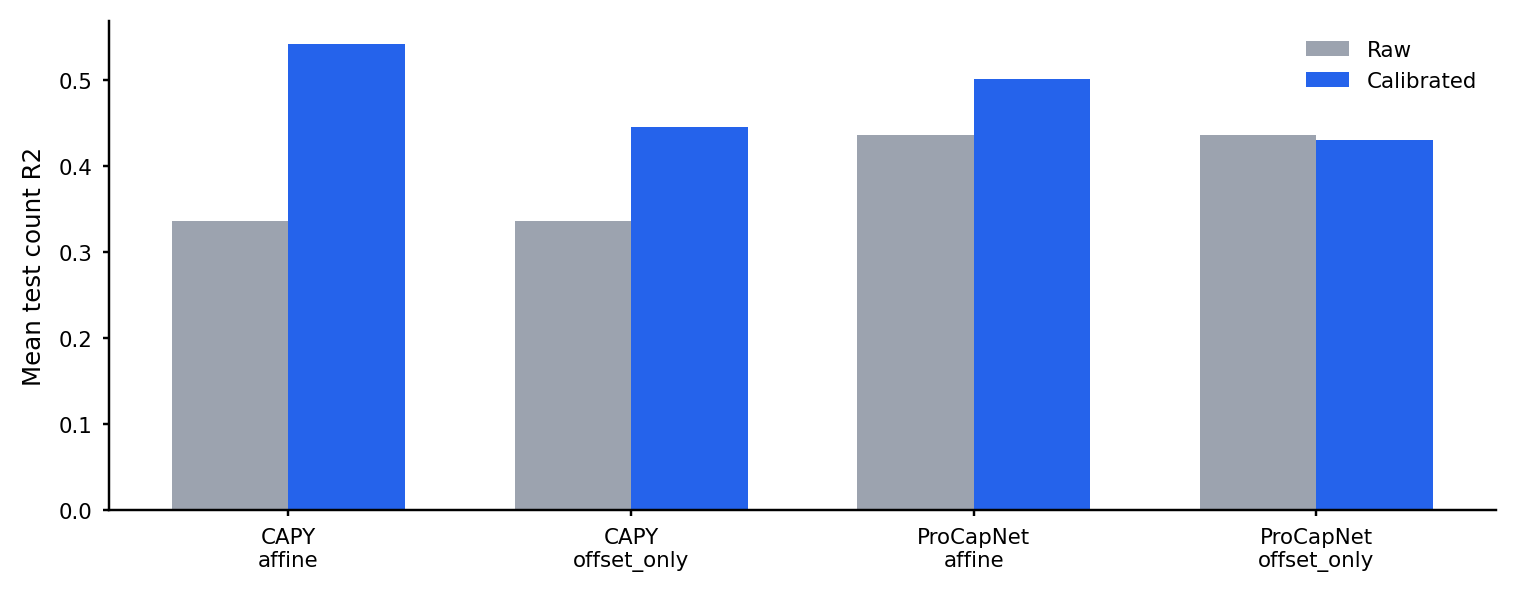

saved: examples/procap/figures_count_calibration/count_r2_comparison.pdf


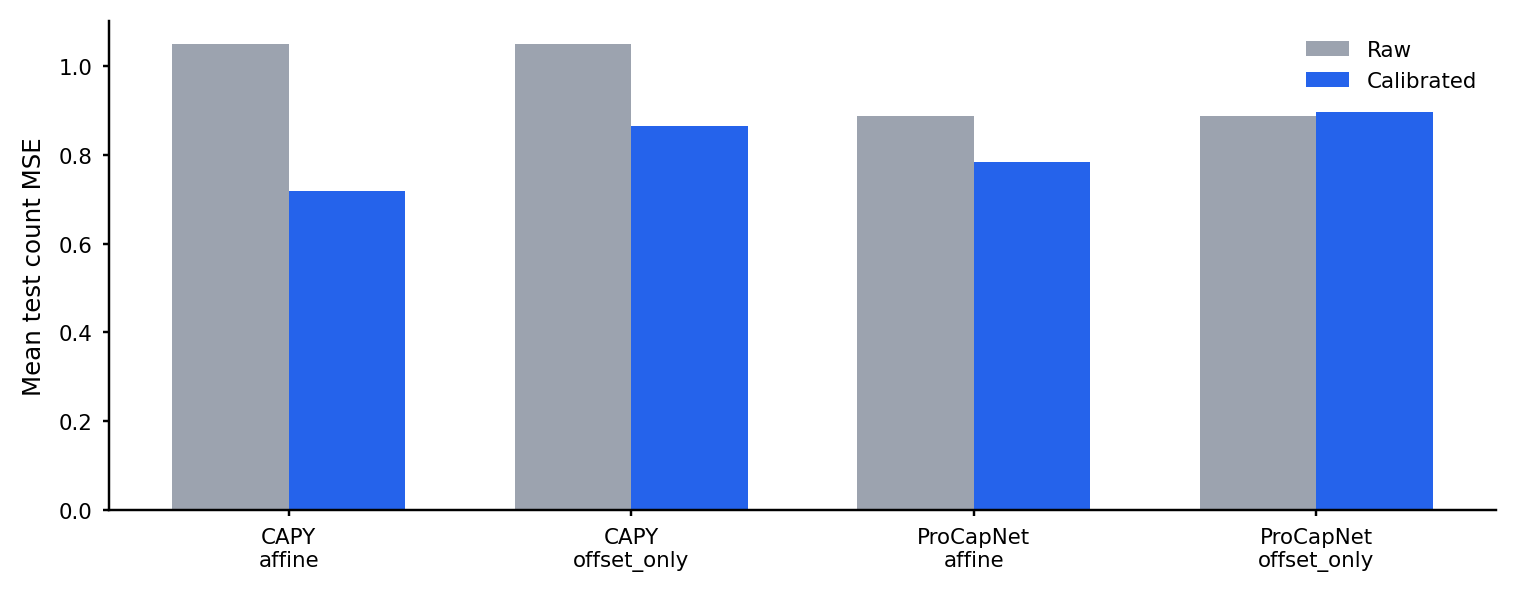

saved: examples/procap/figures_count_calibration/count_mse_comparison.pdf


In [8]:
def plot_metric_comparison(metric_raw: str, metric_calibrated: str, ylabel: str, out_name: str) -> None:
    rows = []
    for _, row in summary_df.iterrows():
        rows.append({"model": row["model"], "mode": row["mode"], "stage": "Raw", "value": row[metric_raw]})
        rows.append({"model": row["model"], "mode": row["mode"], "stage": "Calibrated", "value": row[metric_calibrated]})
    plot_df = pd.DataFrame(rows)
    labels = [f"{model}\n{mode}" for model, mode in plot_df[["model", "mode"]].drop_duplicates().itertuples(index=False, name=None)]
    positions = np.arange(len(labels))
    width = 0.34
    raw_vals = []
    cal_vals = []
    for model, mode in plot_df[["model", "mode"]].drop_duplicates().itertuples(index=False, name=None):
        raw_vals.append(float(plot_df[(plot_df.model == model) & (plot_df["mode"] == mode) & (plot_df.stage == "Raw")]["value"].iloc[0]))
        cal_vals.append(float(plot_df[(plot_df.model == model) & (plot_df["mode"] == mode) & (plot_df.stage == "Calibrated")]["value"].iloc[0]))

    fig, ax = plt.subplots(figsize=(7.0, 2.8), dpi=220)
    ax.bar(positions - width / 2, raw_vals, width=width, color="#9CA3AF", label="Raw")
    ax.bar(positions + width / 2, cal_vals, width=width, color="#2563EB", label="Calibrated")
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.tick_params(length=2, labelsize=7)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, fontsize=7)
    fig.tight_layout()
    out = figures_dir / out_name
    fig.savefig(out, bbox_inches="tight", pad_inches=0.02)
    plt.show()
    print("saved:", out)


plot_metric_comparison("raw_count_r2", "calibrated_count_r2", "Mean test count R2", "count_r2_comparison.pdf")
plot_metric_comparison("raw_count_mse", "calibrated_count_mse", "Mean test count MSE", "count_mse_comparison.pdf")


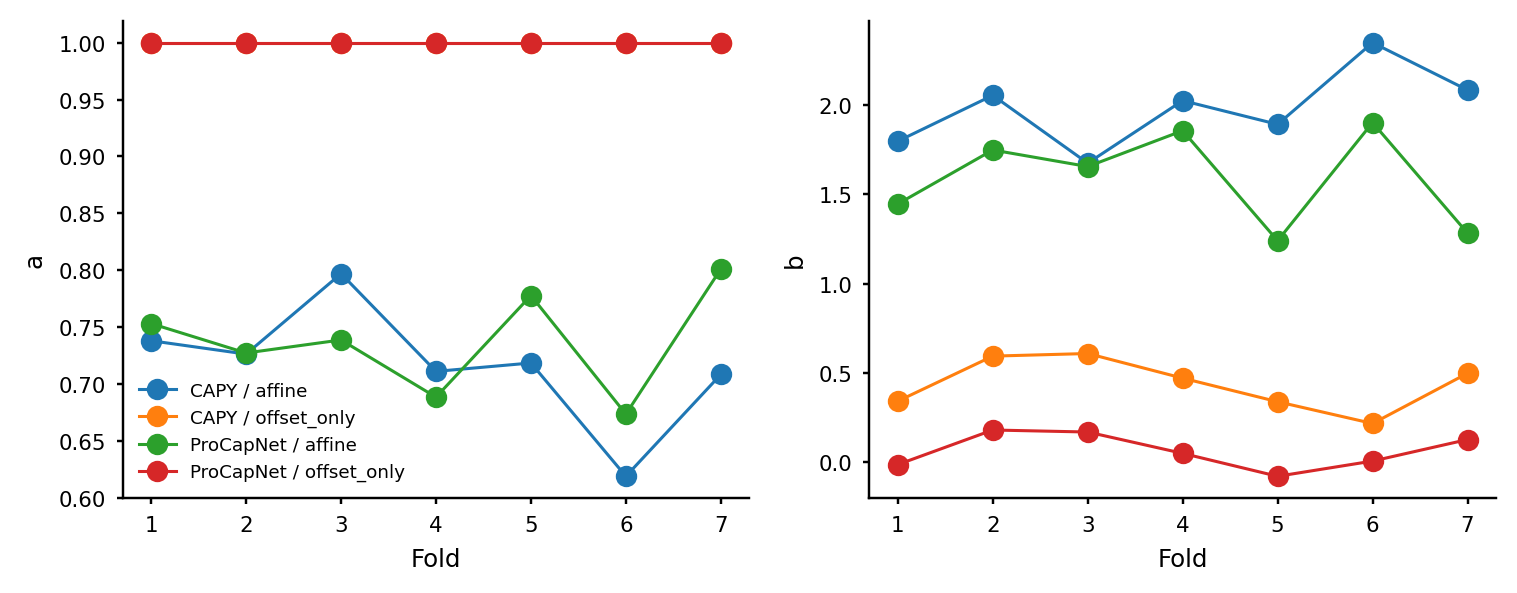

saved: examples/procap/figures_count_calibration/calibration_parameters_by_fold.pdf


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.8), dpi=220)
for ax, param in zip(axes, ["a", "b"]):
    for (model, mode), group in calibration_params_df.groupby(["model", "mode"]):
        ax.plot(group["fold"], group[param], marker="o", linewidth=1.0, label=f"{model} / {mode}")
    ax.set_xlabel("Fold", fontsize=8)
    ax.set_ylabel(param, fontsize=8)
    ax.tick_params(length=2, labelsize=7)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(frameon=False, fontsize=6, ncol=1)
fig.tight_layout()
out = figures_dir / "calibration_parameters_by_fold.pdf"
fig.savefig(out, bbox_inches="tight", pad_inches=0.02)
plt.show()
print("saved:", out)
